# Detecting Suspicious Bug-Fix Patterns in Open-Source GitHub Repositories

This notebook facilitates the analysis of GitHub commits to identify and categorize bugs.


The goal is to compare how a bug is described in issue/PR discussions with what the actual code patch changes. Large mismatches between the narrative and the technical patch may reveal cases that deserve closer manual inspection, including security-sensitive fixes, hidden vulnerabilities, accidental regressions, or potentially suspicious behavior.

In [ ]:
# ============================================================
# Block 1: Initialization
# Project: Narrative–Technical Drift in GitHub Bug Fixes
# ============================================================

!pip install -q requests pandas numpy matplotlib seaborn tqdm python-dateutil pyarrow

import os
import time
import json
import math
import re
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dateutil import parser
from datetime import datetime, timezone

# ----------------------------
# Plot styling
# ----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)

# ----------------------------
# Repositories
# ----------------------------
# Start with TEST_REPOS. Scale to REPOS once the pipeline works.
TEST_REPOS = [
    "python/cpython",
    "nodejs/node",
    "microsoft/vscode",
]

REPOS = [
    "python/cpython",
    "nodejs/node",
    "microsoft/vscode",
    "kubernetes/kubernetes",
    "Homebrew/homebrew-core",
    "rust-lang/rust",
    "golang/go",
    "rails/rails",
]

# ----------------------------
# settings
# ----------------------------
MAX_ISSUE_PAGES_PER_REPO = 3
MAX_ISSUES_PER_REPO = 200

# ----------------------------
# Narrative severity keywords
# ----------------------------
HIGH_SEVERITY_WORDS = [
    "critical",
    "crash",
    "crashes",
    "crashing",
    "data loss",
    "security",
    "vulnerability",
    "exploit",
    "corruption",
    "panic",
    "segfault",
    "segmentation fault",
    "broken",
    "regression",
    "production",
    "outage",
    "denial of service",
    "dos",
    "hang",
    "infinite loop",
    "memory leak",
    "race condition",
    "deadlock",
    "incorrect result",
    "wrong result",
]

LOW_SEVERITY_WORDS = [
    "minor",
    "typo",
    "cleanup",
    "edge case",
    "small",
    "simple",
    "refactor",
    "cosmetic",
    "documentation",
    "docs",
    "comment",
    "formatting",
    "style",
    "lint",
]

# ----------------------------
# Sensitive file patterns
# ----------------------------
# These do NOT mean maliciousness.
# They only mean the PR touches reliability/security-sensitive areas.
SENSITIVE_PATTERNS = [
    "auth",
    "authentication",
    "authorization",
    "security",
    "crypto",
    "password",
    "secret",
    "token",
    "permission",
    "sandbox",
    "parser",
    "deserialize",
    "serialize",
    "network",
    "http",
    "https",
    "ssl",
    "tls",
    "login",
    "session",
    "cookie",
    "privilege",
    "memory",
    "buffer",
    "overflow",
]

# ----------------------------
# GitHub token
# ----------------------------
# In Colab:
# 1. Click the key icon on the left sidebar.
# 2. Add secret named GITHUB_TOKEN.
# 3. Paste your GitHub token.
# 4. Enable notebook access.

try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
except Exception:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")

HEADERS = {
    "Accept": "application/vnd.github+json",
    "User-Agent": "github-narrative-drift-project",
}

if GITHUB_TOKEN:
    HEADERS["Authorization"] = f"Bearer {GITHUB_TOKEN}"

print("Initialization complete.")
print(f"Using GitHub token: {'yes' if GITHUB_TOKEN else 'no'}")

Initialization complete.
Using GitHub token: yes


In [ ]:
# ============================================================
# Block 2: GitHub API Helpers
# ============================================================

def github_get(url, params=None, sleep_on_rate_limit=True, verbose=False):
    """
    Safe GitHub GET request helper.
    Returns JSON on success, None on failure.
    """

    response = requests.get(
        url,
        headers=HEADERS,
        params=params,
        timeout=30
    )

    # Rate limit handling
    if response.status_code == 403:
        remaining = response.headers.get("X-RateLimit-Remaining")
        reset_time = response.headers.get("X-RateLimit-Reset")

        if verbose:
            print("403 response.")
            print("Remaining:", remaining)
            print("Reset:", reset_time)
            print(response.text[:500])

        if sleep_on_rate_limit and remaining == "0" and reset_time:
            reset_timestamp = int(reset_time)
            now_timestamp = int(time.time())
            wait_seconds = max(reset_timestamp - now_timestamp + 5, 0)

            print(f"Rate limit hit. Sleeping {wait_seconds} seconds...")
            time.sleep(wait_seconds)

            response = requests.get(
                url,
                headers=HEADERS,
                params=params,
                timeout=30
            )

    if response.status_code != 200:
        print(f"Request failed: {response.status_code}")
        print("URL:", url)
        print("Params:", params)
        print(response.text[:500])
        return None

    return response.json()


def check_rate_limit():
    """
    Print GitHub API rate limit status.
    """
    url = "https://api.github.com/rate_limit"
    data = github_get(url)

    if data is None:
        print("Could not check rate limit.")
        return None

    core = data.get("resources", {}).get("core", {})
    search = data.get("resources", {}).get("search", {})

    print("Core API:")
    print(f"  Remaining: {core.get('remaining')} / {core.get('limit')}")

    print("Search API:")
    print(f"  Remaining: {search.get('remaining')} / {search.get('limit')}")

    return data


def clean_text(text):
    if text is None:
        return ""
    return str(text)


def zscore(series):
    std = series.std()

    if std == 0 or pd.isna(std):
        return series * 0

    return (series - series.mean()) / std


def days_between(start, end):
    if not start or not end:
        return np.nan

    start_dt = parser.parse(start)
    end_dt = parser.parse(end)

    return (end_dt - start_dt).days


check_rate_limit()

Core API:
  Remaining: 5000 / 5000
Search API:
  Remaining: 30 / 30


{'resources': {'core': {'limit': 5000,
   'used': 0,
   'remaining': 5000,
   'reset': 1777475608},
  'search': {'limit': 30, 'used': 0, 'remaining': 30, 'reset': 1777472068},
  'graphql': {'limit': 5000,
   'used': 0,
   'remaining': 5000,
   'reset': 1777475608},
  'integration_manifest': {'limit': 5000,
   'used': 0,
   'remaining': 5000,
   'reset': 1777475608},
  'source_import': {'limit': 100,
   'used': 0,
   'remaining': 100,
   'reset': 1777472068},
  'code_scanning_upload': {'limit': 5000,
   'used': 0,
   'remaining': 5000,
   'reset': 1777475608},
  'code_scanning_autofix': {'limit': 10,
   'used': 0,
   'remaining': 10,
   'reset': 1777472068},
  'actions_runner_registration': {'limit': 10000,
   'used': 0,
   'remaining': 10000,
   'reset': 1777475608},
  'scim': {'limit': 15000, 'used': 0, 'remaining': 15000, 'reset': 1777475608},
  'dependency_snapshots': {'limit': 100,
   'used': 0,
   'remaining': 100,
   'reset': 1777472068},
  'dependency_sbom': {'limit': 100,
   'u

In [ ]:
# ============================================================
# Replacement Block 3: Better Issue → PR → Patch Fetch Functions
# Uses issue timeline cross-references instead of weak text search
# ============================================================

def fetch_recent_closed_issues(repo, max_pages=2):
    """
    Fetch recent closed issues from a repo.
    Does not require a 'bug' label because repos use different label systems.
    Skips PRs because GitHub's issues endpoint returns both issues and PRs.
    """
    issues = []
    url = f"https://api.github.com/repos/{repo}/issues"

    for page in range(1, max_pages + 1):
        params = {
            "state": "closed",
            "per_page": 100,
            "page": page,
            "sort": "updated",
            "direction": "desc",
        }

        data = github_get(url, params=params)

        if not data:
            break

        for item in data:
            if "pull_request" not in item:
                issues.append(item)

        if len(data) < 100:
            break

    return issues


def fetch_issue_timeline(repo, issue_number):
    """
    Fetch timeline events for an issue.
    Timeline events can include cross-referenced PRs.
    """
    url = f"https://api.github.com/repos/{repo}/issues/{issue_number}/timeline"

    params = {
        "per_page": 100
    }

    # Timeline endpoint needs this accept header on some setups.
    old_accept = HEADERS.get("Accept")
    HEADERS["Accept"] = "application/vnd.github+json"

    data = github_get(url, params=params)

    if old_accept:
        HEADERS["Accept"] = old_accept

    if data is None:
        return []

    return data


def extract_pr_numbers_from_timeline(repo, issue_number):
    """
    Extract candidate PR numbers from issue timeline cross-reference events.
    """
    timeline = fetch_issue_timeline(repo, issue_number)

    pr_numbers = set()

    for event in timeline:
        source = event.get("source", {})
        issue_obj = source.get("issue", {})

        if not issue_obj:
            continue

        # Cross-referenced PRs appear as issue-like objects with pull_request field.
        if "pull_request" in issue_obj:
            pr_repo_url = issue_obj.get("repository_url", "")
            pr_number = issue_obj.get("number")

            # Only keep PRs from the same repo.
            if pr_repo_url.endswith(f"/repos/{repo}") and pr_number is not None:
                pr_numbers.add(pr_number)

    return sorted(pr_numbers)


def fallback_search_linked_prs(repo, issue_number, max_results=5):
    """
    Fallback search if timeline gives nothing.
    Searches several common issue-closing reference styles.
    """
    url = "https://api.github.com/search/issues"

    queries = [
        f'repo:{repo} is:pr is:merged "#{issue_number}"',
        f'repo:{repo} is:pr is:merged "fixes #{issue_number}"',
        f'repo:{repo} is:pr is:merged "closes #{issue_number}"',
        f'repo:{repo} is:pr is:merged "resolves #{issue_number}"',
        f'repo:{repo} is:pr is:merged "GH-{issue_number}"',
        f'repo:{repo} is:pr is:merged "gh-{issue_number}"',
    ]

    pr_numbers = set()

    for query in queries:
        params = {
            "q": query,
            "per_page": max_results,
        }

        data = github_get(url, params=params)

        if data is None:
            continue

        for item in data.get("items", []):
            pr_numbers.add(item.get("number"))

    return sorted([n for n in pr_numbers if n is not None])


def find_linked_pr_numbers(repo, issue_number):
    """
    Main linkage function.
    Prefer timeline cross-references.
    Fall back to search.
    """
    pr_numbers = extract_pr_numbers_from_timeline(repo, issue_number)

    if len(pr_numbers) == 0:
        pr_numbers = fallback_search_linked_prs(repo, issue_number)

    return pr_numbers


def fetch_pr_details(repo, pr_number):
    """
    Fetch PR metadata.
    """
    url = f"https://api.github.com/repos/{repo}/pulls/{pr_number}"
    return github_get(url)


def fetch_pr_files(repo, pr_number):
    """
    Fetch files changed in a PR.
    """
    files = []
    url = f"https://api.github.com/repos/{repo}/pulls/{pr_number}/files"

    page = 1

    while True:
        params = {
            "per_page": 100,
            "page": page,
        }

        data = github_get(url, params=params)

        if not data:
            break

        files.extend(data)

        if len(data) < 100:
            break

        page += 1

    return files


def extract_issue_labels(issue):
    """
    Convert GitHub label objects into plain label names.
    """
    return [label.get("name", "") for label in issue.get("labels", [])]

In [ ]:
# ============================================================
# Replacement Block 4: Build Joined Dataset with Timeline Linkage
# ============================================================

def build_dataset_for_repo(repo, max_issue_pages=2, max_issues=100):
    """
    Build issue → linked merged PR → patch rows for one repo.
    Uses timeline cross-references first, then fallback search.
    """
    rows = []

    issues = fetch_recent_closed_issues(repo, max_pages=max_issue_pages)

    print(f"\n{repo}")
    print(f"Fetched recent closed issues: {len(issues)}")

    issues = issues[:max_issues]

    linkage_attempts = 0
    linked_count = 0
    multiple_pr_match_count = 0
    unmerged_pr_count = 0

    for issue in tqdm(issues, desc=f"Processing {repo}"):
        issue_number = issue["number"]
        linkage_attempts += 1

        linked_pr_numbers = find_linked_pr_numbers(repo, issue_number)

        if len(linked_pr_numbers) == 0:
            continue

        if len(linked_pr_numbers) > 1:
            multiple_pr_match_count += 1

        # Try PRs until we find a merged one.
        chosen_pr = None
        chosen_pr_number = None

        for pr_number in linked_pr_numbers:
            pr = fetch_pr_details(repo, pr_number)

            if not pr:
                continue

            if pr.get("merged_at") is not None:
                chosen_pr = pr
                chosen_pr_number = pr_number
                break
            else:
                unmerged_pr_count += 1

        if chosen_pr is None:
            continue

        linked_count += 1

        files = fetch_pr_files(repo, chosen_pr_number)

        file_names = [f.get("filename", "") for f in files]
        additions = sum(f.get("additions", 0) for f in files)
        deletions = sum(f.get("deletions", 0) for f in files)

        row = {
            "repo": repo,

            "issue_number": issue_number,
            "issue_title": issue.get("title"),
            "issue_body": issue.get("body"),
            "issue_labels": extract_issue_labels(issue),
            "issue_created_at": issue.get("created_at"),
            "issue_closed_at": issue.get("closed_at"),
            "issue_comments_count": issue.get("comments", 0),
            "issue_url": issue.get("html_url"),

            "pr_number": chosen_pr_number,
            "pr_title": chosen_pr.get("title"),
            "pr_body": chosen_pr.get("body"),
            "pr_created_at": chosen_pr.get("created_at"),
            "pr_merged_at": chosen_pr.get("merged_at"),
            "pr_comments_count": chosen_pr.get("comments", 0),
            "pr_review_comments_count": chosen_pr.get("review_comments", 0),
            "pr_url": chosen_pr.get("html_url"),

            "merge_commit_sha": chosen_pr.get("merge_commit_sha"),

            "files_changed": file_names,
            "num_files_changed": len(file_names),
            "additions": additions,
            "deletions": deletions,
            "total_loc_changed": additions + deletions,

            "linked_pr_match_count": len(linked_pr_numbers),
            "linked_pr_numbers": linked_pr_numbers,
        }

        rows.append(row)

    summary = {
        "repo": repo,
        "issues_checked": linkage_attempts,
        "issues_with_merged_linked_pr": linked_count,
        "multiple_pr_match_count": multiple_pr_match_count,
        "unmerged_pr_count_seen": unmerged_pr_count,
        "rows_created": len(rows),
        "linkage_rate": linked_count / linkage_attempts if linkage_attempts > 0 else 0,
    }

    return rows, summary

In [ ]:
# ============================================================
# Replacement Block 5: Test Pipeline on One Repo
# ============================================================

test_rows, test_summary = build_dataset_for_repo(
    repo="microsoft/vscode",
    max_issue_pages=3,
    max_issues=50
)

test_df = pd.DataFrame(test_rows)

print("\nTest summary:")
print(test_summary)

print("\nShape:")
print(test_df.shape)

display(test_df.head())


microsoft/vscode
Fetched recent closed issues: 234


Processing microsoft/vscode:  32%|███▏      | 16/50 [00:50<01:14,  2.20s/it]

Rate limit hit. Sleeping 14 seconds...


Processing microsoft/vscode:  44%|████▍     | 22/50 [01:26<01:49,  3.93s/it]

Rate limit hit. Sleeping 44 seconds...


...

Processing microsoft/vscode:  96%|█████████▌| 48/50 [06:51<00:15,  7.74s/it]

Rate limit hit. Sleeping 47 seconds...


Processing microsoft/vscode: 100%|██████████| 50/50 [07:46<00:00,  9.33s/it]


Test summary:
{'repo': 'microsoft/vscode', 'issues_checked': 50, 'issues_with_merged_linked_pr': 15, 'multiple_pr_match_count': 11, 'unmerged_pr_count_seen': 1, 'rows_created': 15, 'linkage_rate': 0.3}

Shape:
(15, 25)


,repo,issue_number,issue_title,issue_body,issue_labels,issue_created_at,issue_closed_at,issue_comments_count,issue_url,pr_number,...,pr_review_comments_count,pr_url,merge_commit_sha,files_changed,num_files_changed,additions,deletions,total_loc_changed,linked_pr_match_count,linked_pr_numbers
0,microsoft/vscode,142341,Integrated terminal automatically sends 'Y' wh...,Thank you so much for looking into this 🙏 !\r\...,"[bug, verified, candidate, windows, terminal-c...",2022-02-06T18:22:04Z,2022-02-08T19:59:20Z,13,https://github.com/microsoft/vscode/issues/142341,142432,...,0,https://github.com/microsoft/vscode/pull/142432,d9f91a5cb16fa53cf37624f4d1a1f3fac0866061,[src/vs/workbench/contrib/terminal/common/term...,1,2,4,6,1,[142432]
1,microsoft/vscode,239838,VSCode freezes when opening a terminal,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,"[important, freeze-slow-crash-leak, candidate,...",2025-02-06T18:30:33Z,2025-02-12T13:10:02Z,82,https://github.com/microsoft/vscode/issues/239838,239958,...,0,https://github.com/microsoft/vscode/pull/239958,608fb3070cb12944ecb2944f099510c22c104b5a,"[package-lock.json, package.json, remote/packa...",6,170,170,340,2,"[239958, 239959]"
2,microsoft/vscode,239862,Native context menu hijacks custom one in webv...,\nType: <b>Bug</b>\n\nVS code january... \n\nO...,"[bug, verified, candidate, electron, confirmed...",2025-02-06T23:08:52Z,2025-02-12T08:55:23Z,16,https://github.com/microsoft/vscode/issues/239862,240261,...,0,https://github.com/microsoft/vscode/pull/240261,f6d7908eef37a59a1716b3cce062c78a14530037,"[.npmrc, package.json]",2,2,2,4,1,[240261]
3,microsoft/vscode,260389,"""Open with Code"" old context menu option missi...",\nType: <b>Bug</b>\n\n1. Install Visual Studio...,"[bug, verified, candidate, windows, regression...",2025-08-07T18:54:35Z,2025-08-11T12:53:49Z,17,https://github.com/microsoft/vscode/issues/260389,260960,...,0,https://github.com/microsoft/vscode/pull/260960,61f1c115ad49b3e5eb1b5474006e80ef290a6842,[build/win32/code.iss],1,2,3,5,2,"[260960, 261003]"
4,microsoft/vscode,268324,Debt: Remove `github:jrieken/typescript-format...,https://github.com/microsoft/vscode-copilot-ch...,"[debt, unreleased]",2025-09-25T13:51:13Z,2026-04-29T07:38:33Z,2,https://github.com/microsoft/vscode/issues/268324,312688,...,2,https://github.com/microsoft/vscode/pull/312688,40b9c37eef4b016c8e041c494ffd57ac3dbd09fa,"[build/hygiene.ts, build/lib/formatter.ts, ext...",5,56,94,150,1,[312688]


In [ ]:
# ============================================================
# Replacement Block 5B: Safe Manual Sanity Check
# ============================================================

cols_to_check = [
    "repo",
    "issue_number",
    "issue_title",
    "pr_number",
    "pr_title",
    "merge_commit_sha",
    "num_files_changed",
    "additions",
    "deletions",
    "linked_pr_match_count",
    "issue_url",
    "pr_url",
]

if test_df.empty:
    print("test_df is still empty.")
    print()
    print("Run the debugging block below.")
else:
    existing_cols = [col for col in cols_to_check if col in test_df.columns]

    display(test_df[existing_cols].head(10))

    print("Rows:", len(test_df))
    print("Missing merge_commit_sha:", test_df["merge_commit_sha"].isna().sum())
    print("Missing pr_merged_at:", test_df["pr_merged_at"].isna().sum())
    print("Average files changed:", test_df["num_files_changed"].mean())
    print("Average LOC changed:", test_df["total_loc_changed"].mean())
    print("Rows with multiple matching PRs:", test_df["linked_pr_match_count"].gt(1).sum())

,repo,issue_number,issue_title,pr_number,pr_title,merge_commit_sha,num_files_changed,additions,deletions,linked_pr_match_count,issue_url,pr_url
0,microsoft/vscode,142341,Integrated terminal automatically sends 'Y' wh...,142432,Disable auto replies by default,d9f91a5cb16fa53cf37624f4d1a1f3fac0866061,1,2,4,1,https://github.com/microsoft/vscode/issues/142341,https://github.com/microsoft/vscode/pull/142432
1,microsoft/vscode,239838,VSCode freezes when opening a terminal,239958,xterm@5.6.0-beta.97,608fb3070cb12944ecb2944f099510c22c104b5a,6,170,170,2,https://github.com/microsoft/vscode/issues/239838,https://github.com/microsoft/vscode/pull/239958
2,microsoft/vscode,239862,Native context menu hijacks custom one in webv...,240261,fix: context-menu event emitted twice on macOS,f6d7908eef37a59a1716b3cce062c78a14530037,2,2,2,1,https://github.com/microsoft/vscode/issues/239862,https://github.com/microsoft/vscode/pull/240261
3,microsoft/vscode,260389,"""Open with Code"" old context menu option missi...",260960,fix: restore old style context menu on windows...,61f1c115ad49b3e5eb1b5474006e80ef290a6842,1,2,3,2,https://github.com/microsoft/vscode/issues/260389,https://github.com/microsoft/vscode/pull/260960
4,microsoft/vscode,268324,Debt: Remove `github:jrieken/typescript-format...,312688,refactor: improve formatting verification and ...,40b9c37eef4b016c8e041c494ffd57ac3dbd09fa,5,56,94,1,https://github.com/microsoft/vscode/issues/268324,https://github.com/microsoft/vscode/pull/312688
5,microsoft/vscode,275289,Chat session picker: No picker in restored cha...,283076,chatSessionService#onDidChangeOptionGroups,ae9f2efbab2d593a66a134118151cfd17f233312,4,17,0,2,https://github.com/microsoft/vscode/issues/275289,https://github.com/microsoft/vscode/pull/283076
6,microsoft/vscode,277422,Telemetry event `inline.done` isn't send for v...,277423,Make sure UI sends `notifyUserAction` on accep...,5a49cf9b77dfe22b546390aae02dbd922d66b071,1,18,0,2,https://github.com/microsoft/vscode/issues/277422,https://github.com/microsoft/vscode/pull/277423
7,microsoft/vscode,283017,InlineChatController2 creates widget eagerly,283023,"Make sure not create widget eagerly, enforce e...",d2841596be13640af8292520978cd6dc3ae89694,1,8,7,2,https://github.com/microsoft/vscode/issues/283017,https://github.com/microsoft/vscode/pull/283023
8,microsoft/vscode,286776,Git Source Control Graph tree doesn't expand f...,287020,Git - fix git diff raw parsing to correctly ha...,2c1a2eeb2d6171038856b3737af3283ae19295ae,1,15,4,2,https://github.com/microsoft/vscode/issues/286776,https://github.com/microsoft/vscode/pull/287020
9,microsoft/vscode,295264,Backport fix for CVE-2026-2441 from chromium,295559,chore: bump electron@39.6.0,68931fd75f8010d40545e74d7f8560081f6c1f27,5,87,87,2,https://github.com/microsoft/vscode/issues/295264,https://github.com/microsoft/vscode/pull/295559


Rows: 15
Missing merge_commit_sha: 0
Missing pr_merged_at: 0
Average files changed: 3.2666666666666666
Average LOC changed: 128.86666666666667
Rows with multiple matching PRs: 11


In [ ]:
# ============================================================
# Block 6: Feature Extraction
# ============================================================

def count_keyword_hits(text, keywords):
    text = clean_text(text).lower()
    count = 0

    for word in keywords:
        if word.lower() in text:
            count += 1

    return count


def count_sensitive_files(files_changed):
    if not isinstance(files_changed, list):
        return 0

    count = 0

    for filename in files_changed:
        filename_lower = filename.lower()

        for pattern in SENSITIVE_PATTERNS:
            if pattern in filename_lower:
                count += 1
                break

    return count


def extract_features(df):
    df = df.copy()

    df["issue_text"] = (
        df["issue_title"].fillna("") + " " +
        df["issue_body"].fillna("")
    )

    df["pr_text"] = (
        df["pr_title"].fillna("") + " " +
        df["pr_body"].fillna("")
    )

    df["combined_text"] = df["issue_text"] + " " + df["pr_text"]

    # Narrative features
    df["high_severity_words"] = df["combined_text"].apply(
        lambda x: count_keyword_hits(x, HIGH_SEVERITY_WORDS)
    )

    df["low_severity_words"] = df["combined_text"].apply(
        lambda x: count_keyword_hits(x, LOW_SEVERITY_WORDS)
    )

    df["narrative_severity_score"] = (
        df["high_severity_words"] - df["low_severity_words"]
    )

    # Technical features
    df["sensitive_file_count"] = df["files_changed"].apply(count_sensitive_files)

    df["log_total_loc_changed"] = np.log1p(df["total_loc_changed"])
    df["log_num_files_changed"] = np.log1p(df["num_files_changed"])

    df["technical_risk_score"] = (
        zscore(df["log_total_loc_changed"]) +
        zscore(df["log_num_files_changed"]) +
        zscore(df["sensitive_file_count"])
    )

    # Drift = technical risk is high, but narrative severity is low
    df["drift_score"] = (
        zscore(df["technical_risk_score"]) -
        zscore(df["narrative_severity_score"])
    )

    return df


test_features_df = extract_features(test_df)

display(test_features_df[[
    "repo",
    "issue_number",
    "pr_number",
    "issue_title",
    "pr_title",
    "num_files_changed",
    "total_loc_changed",
    "sensitive_file_count",
    "narrative_severity_score",
    "technical_risk_score",
    "drift_score",
    "issue_url",
    "pr_url",
]].sort_values("drift_score", ascending=False).head(10))

,repo,issue_number,pr_number,issue_title,pr_title,num_files_changed,total_loc_changed,sensitive_file_count,narrative_severity_score,technical_risk_score,drift_score,issue_url,pr_url
4,microsoft/vscode,268324,312688,Debt: Remove `github:jrieken/typescript-format...,refactor: improve formatting verification and ...,5,150,0,-3,0.981253,3.229377,https://github.com/microsoft/vscode/issues/268324,https://github.com/microsoft/vscode/pull/312688
10,microsoft/vscode,303174,304236,autopilot mode should allow curl in terminal,Enable terminal commands to run freely in `Aut...,7,301,1,0,3.075468,1.514256,https://github.com/microsoft/vscode/issues/303174,https://github.com/microsoft/vscode/pull/304236
14,microsoft/vscode,312554,312951,"After Plan mode, agent does not start implemen...","On agent mode change, ignore stateful marker",10,342,1,1,3.678685,0.899499,https://github.com/microsoft/vscode/issues/312554,https://github.com/microsoft/vscode/pull/312951
9,microsoft/vscode,295264,295559,Backport fix for CVE-2026-2441 from chromium,chore: bump electron@39.6.0,5,174,0,0,1.070544,0.604331,https://github.com/microsoft/vscode/issues/295264,https://github.com/microsoft/vscode/pull/295559
5,microsoft/vscode,275289,283076,Chat session picker: No picker in restored cha...,chatSessionService#onDidChangeOptionGroups,4,17,3,1,2.990470,0.587157,https://github.com/microsoft/vscode/issues/275289,https://github.com/microsoft/vscode/pull/283076
1,microsoft/vscode,239838,239958,VSCode freezes when opening a terminal,xterm@5.6.0-beta.97,6,340,0,1,1.729052,0.014668,https://github.com/microsoft/vscode/issues/239838,https://github.com/microsoft/vscode/pull/239958
2,microsoft/vscode,239862,240261,Native context menu hijacks custom one in webv...,fix: context-menu event emitted twice on macOS,2,4,0,-1,-2.226864,-0.003658,https://github.com/microsoft/vscode/issues/239862,https://github.com/microsoft/vscode/pull/240261
3,microsoft/vscode,260389,260960,"""Open with Code"" old context menu option missi...",fix: restore old style context menu on windows...,1,5,0,-1,-2.786416,-0.257608,https://github.com/microsoft/vscode/issues/260389,https://github.com/microsoft/vscode/pull/260960
13,microsoft/vscode,313148,313205,Deleting forked session deleted my worktree,Fix deleting forked session showing wrong conf...,1,14,1,0,-1.032438,-0.350097,https://github.com/microsoft/vscode/issues/313148,https://github.com/microsoft/vscode/pull/313205
12,microsoft/vscode,309608,309596,`send_to_terminal` progress message repeats fi...,Skip redundant `send_to_terminal` confirmation...,2,264,0,1,0.176493,-0.689953,https://github.com/microsoft/vscode/issues/309608,https://github.com/microsoft/vscode/pull/309596


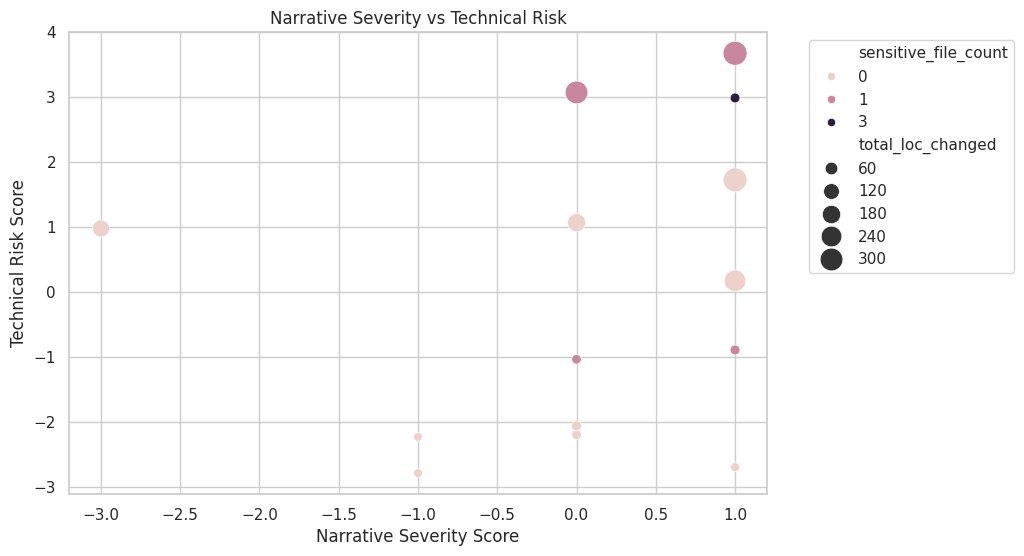

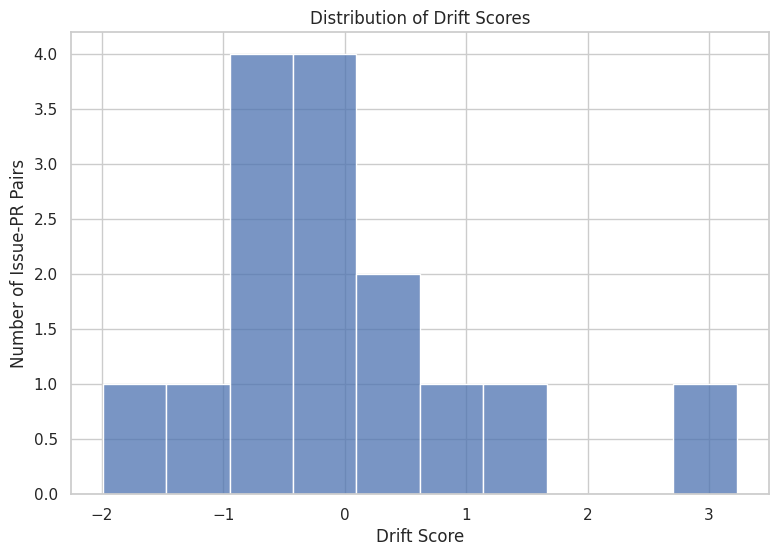

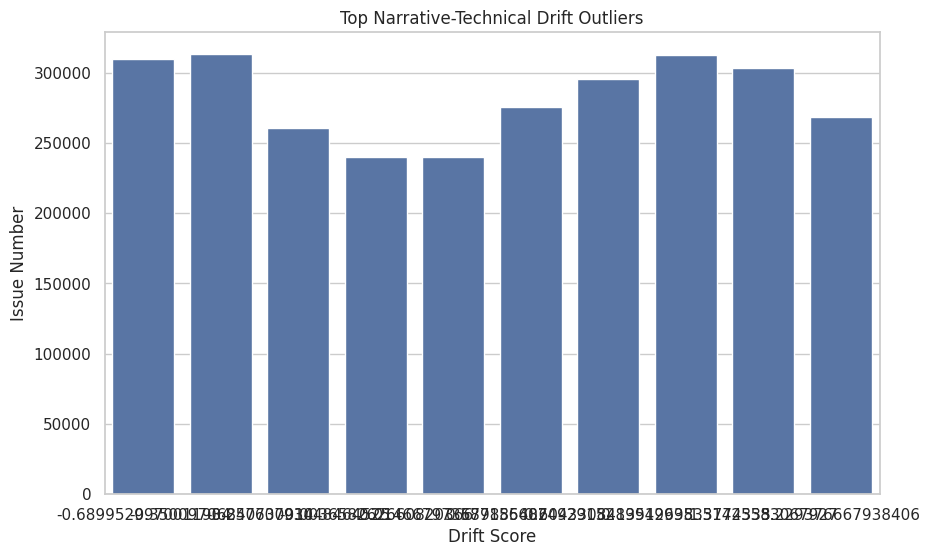

In [ ]:
# ============================================================
# Block 7: Basic Plots
# ============================================================

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=test_features_df,
    x="narrative_severity_score",
    y="technical_risk_score",
    size="total_loc_changed",
    hue="sensitive_file_count",
    sizes=(40, 300)
)

plt.title("Narrative Severity vs Technical Risk")
plt.xlabel("Narrative Severity Score")
plt.ylabel("Technical Risk Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


plt.figure(figsize=(9, 6))
sns.histplot(test_features_df["drift_score"], bins=10)

plt.title("Distribution of Drift Scores")
plt.xlabel("Drift Score")
plt.ylabel("Number of Issue-PR Pairs")
plt.show()


top_outliers = test_features_df.sort_values(
    "drift_score",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_outliers,
    x="drift_score",
    y="issue_number"
)

plt.title("Top Narrative-Technical Drift Outliers")
plt.xlabel("Drift Score")
plt.ylabel("Issue Number")
plt.show()

In [ ]:
# ============================================================
# Block 8: Manual Inspection Table
# ============================================================

manual_review_df = test_features_df.sort_values(
    "drift_score",
    ascending=False
)[[
    "repo",
    "issue_number",
    "pr_number",
    "issue_title",
    "pr_title",
    "files_changed",
    "num_files_changed",
    "total_loc_changed",
    "sensitive_file_count",
    "narrative_severity_score",
    "technical_risk_score",
    "drift_score",
    "issue_url",
    "pr_url",
]].head(10)

display(manual_review_df)

,repo,issue_number,pr_number,issue_title,pr_title,files_changed,num_files_changed,total_loc_changed,sensitive_file_count,narrative_severity_score,technical_risk_score,drift_score,issue_url,pr_url
4,microsoft/vscode,268324,312688,Debt: Remove `github:jrieken/typescript-format...,refactor: improve formatting verification and ...,"[build/hygiene.ts, build/lib/formatter.ts, ext...",5,150,0,-3,0.981253,3.229377,https://github.com/microsoft/vscode/issues/268324,https://github.com/microsoft/vscode/pull/312688
10,microsoft/vscode,303174,304236,autopilot mode should allow curl in terminal,Enable terminal commands to run freely in `Aut...,[src/vs/workbench/contrib/chat/browser/widget/...,7,301,1,0,3.075468,1.514256,https://github.com/microsoft/vscode/issues/303174,https://github.com/microsoft/vscode/pull/304236
14,microsoft/vscode,312554,312951,"After Plan mode, agent does not start implemen...","On agent mode change, ignore stateful marker",[extensions/copilot/src/extension/agents/vscod...,10,342,1,1,3.678685,0.899499,https://github.com/microsoft/vscode/issues/312554,https://github.com/microsoft/vscode/pull/312951
9,microsoft/vscode,295264,295559,Backport fix for CVE-2026-2441 from chromium,chore: bump electron@39.6.0,"[.npmrc, build/checksums/electron.txt, cgmanif...",5,174,0,0,1.070544,0.604331,https://github.com/microsoft/vscode/issues/295264,https://github.com/microsoft/vscode/pull/295559
5,microsoft/vscode,275289,283076,Chat session picker: No picker in restored cha...,chatSessionService#onDidChangeOptionGroups,[src/vs/workbench/contrib/chat/browser/chatInp...,4,17,3,1,2.990470,0.587157,https://github.com/microsoft/vscode/issues/275289,https://github.com/microsoft/vscode/pull/283076
1,microsoft/vscode,239838,239958,VSCode freezes when opening a terminal,xterm@5.6.0-beta.97,"[package-lock.json, package.json, remote/packa...",6,340,0,1,1.729052,0.014668,https://github.com/microsoft/vscode/issues/239838,https://github.com/microsoft/vscode/pull/239958
2,microsoft/vscode,239862,240261,Native context menu hijacks custom one in webv...,fix: context-menu event emitted twice on macOS,"[.npmrc, package.json]",2,4,0,-1,-2.226864,-0.003658,https://github.com/microsoft/vscode/issues/239862,https://github.com/microsoft/vscode/pull/240261
3,microsoft/vscode,260389,260960,"""Open with Code"" old context menu option missi...",fix: restore old style context menu on windows...,[build/win32/code.iss],1,5,0,-1,-2.786416,-0.257608,https://github.com/microsoft/vscode/issues/260389,https://github.com/microsoft/vscode/pull/260960
13,microsoft/vscode,313148,313205,Deleting forked session deleted my worktree,Fix deleting forked session showing wrong conf...,[src/vs/sessions/contrib/copilotChatSessions/b...,1,14,1,0,-1.032438,-0.350097,https://github.com/microsoft/vscode/issues/313148,https://github.com/microsoft/vscode/pull/313205
12,microsoft/vscode,309608,309596,`send_to_terminal` progress message repeats fi...,Skip redundant `send_to_terminal` confirmation...,[src/vs/workbench/contrib/terminalContrib/chat...,2,264,0,1,0.176493,-0.689953,https://github.com/microsoft/vscode/issues/309608,https://github.com/microsoft/vscode/pull/309596


In [ ]:
# ============================================================
# Block 9: Simple Security-Relevance Label
# ============================================================

SECURITY_WORDS = [
    "security",
    "vulnerability",
    "cve",
    "ghsa",
    "exploit",
    "attack",
    "attacker",
    "malicious",
    "permission",
    "privilege",
    "auth",
    "authentication",
    "authorization",
    "token",
    "secret",
    "password",
    "sandbox",
    "xss",
    "csrf",
    "rce",
    "denial of service",
    "dos",
]


def is_security_relevant(row):
    text = clean_text(row.get("combined_text", "")).lower()

    has_security_language = any(
        word in text for word in SECURITY_WORDS
    )

    touches_sensitive_file = row.get("sensitive_file_count", 0) > 0

    return int(has_security_language or touches_sensitive_file)


test_features_df["security_relevant_v1"] = test_features_df.apply(
    is_security_relevant,
    axis=1
)

display(test_features_df[[
    "repo",
    "issue_number",
    "pr_number",
    "issue_title",
    "pr_title",
    "security_relevant_v1",
    "sensitive_file_count",
    "narrative_severity_score",
    "technical_risk_score",
    "drift_score",
    "issue_url",
    "pr_url",
]].sort_values("drift_score", ascending=False).head(10))

,repo,issue_number,pr_number,issue_title,pr_title,security_relevant_v1,sensitive_file_count,narrative_severity_score,technical_risk_score,drift_score,issue_url,pr_url
4,microsoft/vscode,268324,312688,Debt: Remove `github:jrieken/typescript-format...,refactor: improve formatting verification and ...,1,0,-3,0.981253,3.229377,https://github.com/microsoft/vscode/issues/268324,https://github.com/microsoft/vscode/pull/312688
10,microsoft/vscode,303174,304236,autopilot mode should allow curl in terminal,Enable terminal commands to run freely in `Aut...,1,1,0,3.075468,1.514256,https://github.com/microsoft/vscode/issues/303174,https://github.com/microsoft/vscode/pull/304236
14,microsoft/vscode,312554,312951,"After Plan mode, agent does not start implemen...","On agent mode change, ignore stateful marker",1,1,1,3.678685,0.899499,https://github.com/microsoft/vscode/issues/312554,https://github.com/microsoft/vscode/pull/312951
9,microsoft/vscode,295264,295559,Backport fix for CVE-2026-2441 from chromium,chore: bump electron@39.6.0,1,0,0,1.070544,0.604331,https://github.com/microsoft/vscode/issues/295264,https://github.com/microsoft/vscode/pull/295559
5,microsoft/vscode,275289,283076,Chat session picker: No picker in restored cha...,chatSessionService#onDidChangeOptionGroups,1,3,1,2.990470,0.587157,https://github.com/microsoft/vscode/issues/275289,https://github.com/microsoft/vscode/pull/283076
1,microsoft/vscode,239838,239958,VSCode freezes when opening a terminal,xterm@5.6.0-beta.97,1,0,1,1.729052,0.014668,https://github.com/microsoft/vscode/issues/239838,https://github.com/microsoft/vscode/pull/239958
2,microsoft/vscode,239862,240261,Native context menu hijacks custom one in webv...,fix: context-menu event emitted twice on macOS,1,0,-1,-2.226864,-0.003658,https://github.com/microsoft/vscode/issues/239862,https://github.com/microsoft/vscode/pull/240261
3,microsoft/vscode,260389,260960,"""Open with Code"" old context menu option missi...",fix: restore old style context menu on windows...,1,0,-1,-2.786416,-0.257608,https://github.com/microsoft/vscode/issues/260389,https://github.com/microsoft/vscode/pull/260960
13,microsoft/vscode,313148,313205,Deleting forked session deleted my worktree,Fix deleting forked session showing wrong conf...,1,1,0,-1.032438,-0.350097,https://github.com/microsoft/vscode/issues/313148,https://github.com/microsoft/vscode/pull/313205
12,microsoft/vscode,309608,309596,`send_to_terminal` progress message repeats fi...,Skip redundant `send_to_terminal` confirmation...,1,0,1,0.176493,-0.689953,https://github.com/microsoft/vscode/issues/309608,https://github.com/microsoft/vscode/pull/309596


/tmp/ipykernel_1671/2123945222.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_summary = test_features_df.groupby("drift_quartile").agg(


,drift_quartile,rows,avg_drift,avg_security_relevant,avg_loc_changed,avg_files_changed,avg_sensitive_files
0,Q1 lowest drift,4,-1.214505,1.0,14.500000,1.00,0.25
1,Q2,4,-0.496903,1.0,136.750000,1.50,0.25
2,Q3,3,0.199389,1.0,120.333333,4.00,1.00
3,Q4 highest drift,4,1.561866,1.0,241.750000,6.75,0.50


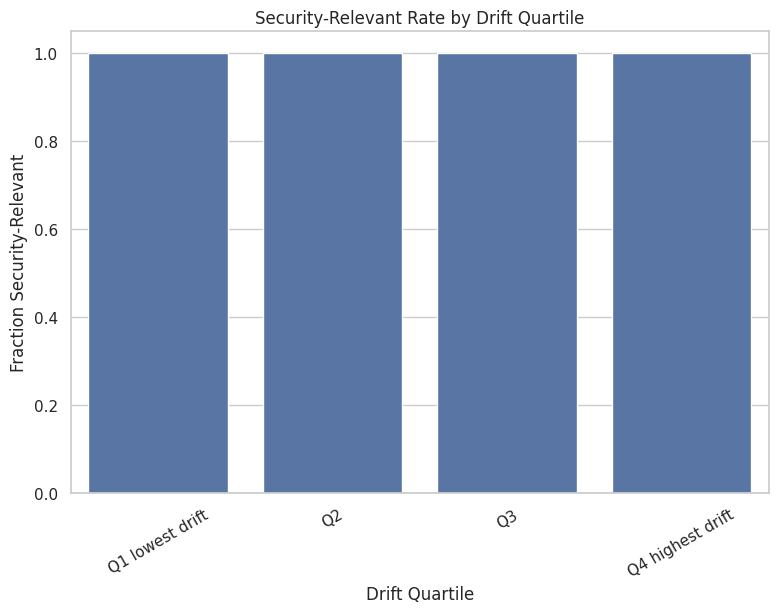

In [ ]:
# ============================================================
# Block 10: Drift Quartile Analysis
# ============================================================

if len(test_features_df) < 4:
    print("Not enough rows for quartile analysis.")
else:
    test_features_df["drift_quartile"] = pd.qcut(
        test_features_df["drift_score"],
        q=4,
        labels=["Q1 lowest drift", "Q2", "Q3", "Q4 highest drift"],
        duplicates="drop"
    )

    quartile_summary = test_features_df.groupby("drift_quartile").agg(
        rows=("drift_score", "count"),
        avg_drift=("drift_score", "mean"),
        avg_security_relevant=("security_relevant_v1", "mean"),
        avg_loc_changed=("total_loc_changed", "mean"),
        avg_files_changed=("num_files_changed", "mean"),
        avg_sensitive_files=("sensitive_file_count", "mean")
    ).reset_index()

    display(quartile_summary)

    plt.figure(figsize=(9, 6))

    sns.barplot(
        data=quartile_summary,
        x="drift_quartile",
        y="avg_security_relevant"
    )

    plt.title("Security-Relevant Rate by Drift Quartile")
    plt.xlabel("Drift Quartile")
    plt.ylabel("Fraction Security-Relevant")
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
# ============================================================
# Block 11: Scale Pipeline to All Repositories
# ============================================================

all_rows = []
all_summaries = []

for repo in REPOS:
    rows, summary = build_dataset_for_repo(
        repo=repo,
        max_issue_pages=MAX_ISSUE_PAGES_PER_REPO,
        max_issues=MAX_ISSUES_PER_REPO
    )

    all_rows.extend(rows)
    all_summaries.append(summary)

github_df = pd.DataFrame(all_rows)
summary_df = pd.DataFrame(all_summaries)

print("GitHub dataset shape:", github_df.shape)

display(summary_df)
display(github_df.head())


python/cpython
Fetched recent closed issues: 94


Processing python/cpython:  20%|██        | 19/94 [00:57<03:14,  2.60s/it]

Rate limit hit. Sleeping 26 seconds...


Processing python/cpython:  43%|████▎     | 40/94 [02:17<02:02,  2.27s/it]

Rate limit hit. Sleeping 11 seconds...


...

Rate limit hit. Sleeping 27 seconds...


Processing rails/rails: 100%|██████████| 69/69 [06:16<00:00,  5.45s/it]

GitHub dataset shape: (248, 25)


,repo,issues_checked,issues_with_merged_linked_pr,multiple_pr_match_count,unmerged_pr_count_seen,rows_created,linkage_rate
0,python/cpython,94,59,43,22,59,0.627660
1,nodejs/node,62,45,12,13,45,0.725806
2,microsoft/vscode,200,34,15,4,34,0.170000
3,kubernetes/kubernetes,77,47,28,30,47,0.610390
4,Homebrew/homebrew-core,0,0,0,0,0,0.000000
5,rust-lang/rust,50,41,11,7,41,0.820000
6,golang/go,200,0,1,8,0,0.000000
7,rails/rails,69,22,10,28,22,0.318841


,repo,issue_number,issue_title,issue_body,issue_labels,issue_created_at,issue_closed_at,issue_comments_count,issue_url,pr_number,...,pr_review_comments_count,pr_url,merge_commit_sha,files_changed,num_files_changed,additions,deletions,total_loc_changed,linked_pr_match_count,linked_pr_numbers
0,python/cpython,149122,Segfault with async generator expressions,# Crash report\n\n### What happened?\n\nRunnin...,"[interpreter-core, type-crash, 3.14, 3.15]",2026-04-29T00:33:38Z,2026-04-29T13:35:53Z,2,https://github.com/python/cpython/issues/149122,149138,...,0,https://github.com/python/cpython/pull/149138,16f292ef4e8c56bfd115ecdb91420c7b4006249f,"[Lib/test/test_builtin.py, Misc/NEWS.d/next/Co...",3,31,1,32,2,"[149138, 149151]"
1,python/cpython,144538,Update bundled pip to 26.0.1,Python 3.10's bundled pip (23.0.1) and setupto...,"[type-feature, stdlib, topic-ensurepip, depend...",2026-02-06T10:07:06Z,2026-02-07T12:27:48Z,18,https://github.com/python/cpython/issues/144538,144556,...,0,https://github.com/python/cpython/pull/144556,f4364a51c1a8ce682fe9e4e96c6aba9f1b590422,"[Lib/ensurepip/__init__.py, Lib/ensurepip/_bun...",3,2,1,3,5,"[144539, 144556, 144561, 144562, 149150]"
2,python/cpython,135528,Support more second-level domain names in http...,# Feature or enhancement\n\n### Proposal:\n\ni...,"[type-feature, stdlib]",2025-06-15T03:30:53Z,2026-04-29T12:38:14Z,1,https://github.com/python/cpython/issues/135528,135820,...,3,https://github.com/python/cpython/pull/135820,4a5d25c26c01a04c0ddef1a0b00cb55cc835034f,"[Lib/http/cookiejar.py, Misc/NEWS.d/next/Libra...",2,8,4,12,3,"[135529, 135569, 135820]"
3,python/cpython,133346,Theming support for _colorize,"As mentioned in #131507 and #130645, theming s...","[type-feature, stdlib]",2025-05-03T15:12:13Z,2025-05-21T10:36:12Z,2,https://github.com/python/cpython/issues/133346,133347,...,40,https://github.com/python/cpython/pull/133347,f610bbdf74ea580b14353c6bfd08fd00bcbfa11e,"[Doc/whatsnew/3.14.rst, Lib/_colorize.py, Lib/...",20,581,367,948,8,"[119966, 133347, 133380, 139687, 140620, 14062..."
4,python/cpython,140287,The asyncio REPL interactive daemon thread doe...,# Bug report\n\n### Bug description:\n\nThat l...,"[type-bug, topic-asyncio, stdlib, 3.13, 3.14, ...",2025-10-18T09:57:08Z,2026-04-29T09:57:29Z,4,https://github.com/python/cpython/issues/140287,140288,...,15,https://github.com/python/cpython/pull/140288,5ea3ae7c97f06cebcbbe81b142ee4a2b23d980e9,"[Lib/asyncio/__main__.py, Lib/test/test_repl.p...",3,51,6,57,3,"[140288, 148987, 148988]"


In [ ]:
# ============================================================
# Block 12: Extract Features on Full GitHub Dataset
# ============================================================

github_features_df = extract_features(github_df)

github_features_df["security_relevant_v1"] = github_features_df.apply(
    is_security_relevant,
    axis=1
)

print("Feature dataset shape:", github_features_df.shape)

display(github_features_df[[
    "repo",
    "issue_number",
    "pr_number",
    "issue_title",
    "pr_title",
    "num_files_changed",
    "total_loc_changed",
    "sensitive_file_count",
    "narrative_severity_score",
    "technical_risk_score",
    "drift_score",
    "security_relevant_v1",
    "issue_url",
    "pr_url",
]].sort_values("drift_score", ascending=False).head(20))

Feature dataset shape: (248, 37)


,repo,issue_number,pr_number,issue_title,pr_title,num_files_changed,total_loc_changed,sensitive_file_count,narrative_severity_score,technical_risk_score,drift_score,security_relevant_v1,issue_url,pr_url
77,nodejs/node,59933,53522,Use `C:/` path searching in windows over `C:\`,deps: V8: cherry-pick 9ebca66a5740,58,275,21,1,15.026458,5.542984,1,https://github.com/nodejs/node/issues/59933,https://github.com/nodejs/node/pull/53522
184,kubernetes/kubernetes,136986,136976,[Umbrella] KEP-5832 / KEP-4671: Decouple PodGr...,Create Workload API v1alpha2,248,18004,5,-2,9.605994,5.258583,1,https://github.com/kubernetes/kubernetes/issue...,https://github.com/kubernetes/kubernetes/pull/...
90,nodejs/node,60423,60012,allocUnsafe is useless since 24,deps: upgrade npm to 11.6.1,1030,82372,4,0,11.307692,4.638319,1,https://github.com/nodejs/node/issues/60423,https://github.com/nodejs/node/pull/60012
71,nodejs/node,62899,62902,Key usages should be an unique set,crypto: deduplicate and canonicalize CryptoKey...,12,645,12,0,8.786253,3.570284,1,https://github.com/nodejs/node/issues/62899,https://github.com/nodejs/node/pull/62902
22,python/cpython,148991,148992,Add colour to `tokenize` CLI output,gh-148991: Add colour to `tokenize` CLI output,6,97,3,-4,2.019207,3.386031,1,https://github.com/python/cpython/issues/148991,https://github.com/python/cpython/pull/148992
223,rust-lang/rust,133469,120639,test issue,Implement new effects desugaring,175,3792,0,-1,5.573388,2.879909,1,https://github.com/rust-lang/rust/issues/133469,https://github.com/rust-lang/rust/pull/120639
38,python/cpython,140727,142373,Document new profiling package and restructure...,gh-140727: Restructure profiling documentation...,28,2869,0,-2,3.564737,2.699618,0,https://github.com/python/cpython/issues/140727,https://github.com/python/cpython/pull/142373
26,python/cpython,148981,148982,Add colour to `ast.dump` output,gh-148981: Add color to `ast.dump`,6,108,0,-4,0.365715,2.685642,0,https://github.com/python/cpython/issues/148981,https://github.com/python/cpython/pull/148982
217,rust-lang/rust,153886,154197,Redundant clone suggestion in move error,Avoid redundant clone suggestions in borrowck ...,15,344,0,-3,1.829060,2.634953,1,https://github.com/rust-lang/rust/issues/153886,https://github.com/rust-lang/rust/pull/154197
201,rust-lang/rust,153772,155653,Support `__mulsi3` for m68k,compiler-builtins subtree update,205,14183,0,0,6.434307,2.574043,0,https://github.com/rust-lang/rust/issues/153772,https://github.com/rust-lang/rust/pull/155653


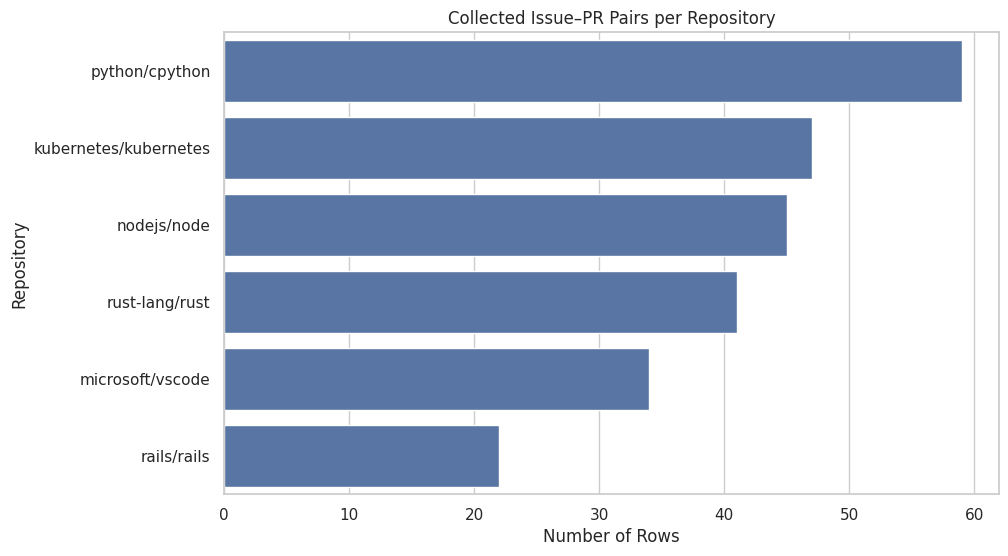

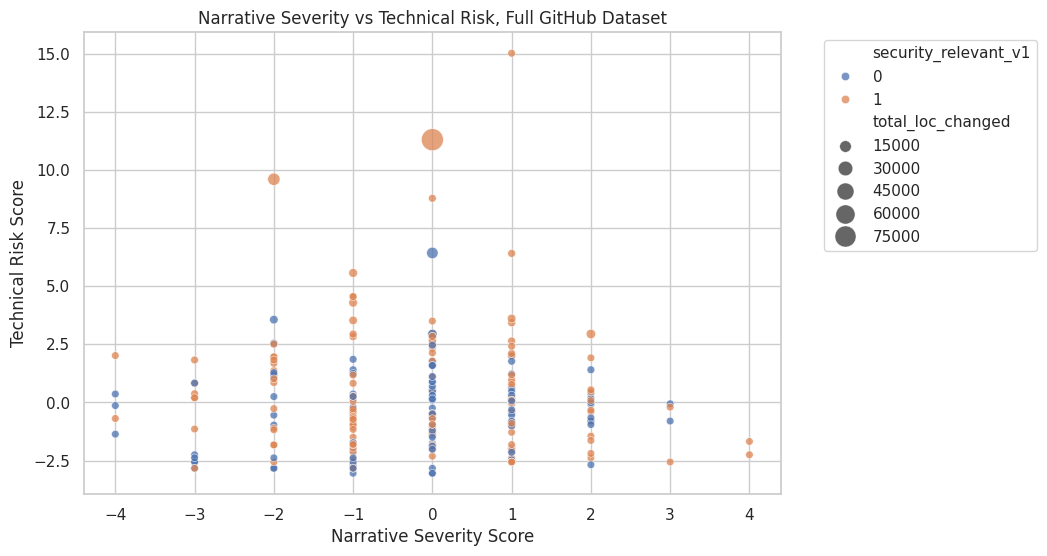

,drift_quartile,rows,avg_drift,security_rate,avg_loc_changed,avg_files_changed,avg_sensitive_files
0,Q1 lowest drift,62,-1.619876,0.548387,46.145161,2.225806,0.112903
1,Q2,62,-0.536328,0.612903,169.435484,2.806452,0.193548
2,Q3,62,0.297709,0.580645,251.032258,5.903226,0.145161
3,Q4 highest drift,62,1.858495,0.629032,2475.338710,39.741935,1.225806


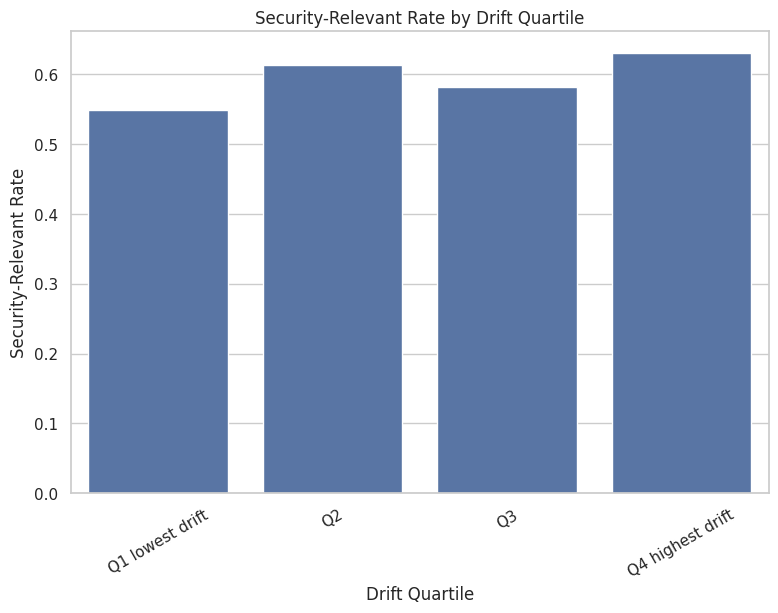

In [ ]:
# ============================================================
# Block 13: Full Dataset Summary Plots
# ============================================================

if github_features_df.empty:
    print("github_features_df is empty. Run Blocks 11 and 12 first.")
else:
    repo_counts = github_features_df.groupby("repo").size().reset_index(name="rows")

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=repo_counts.sort_values("rows", ascending=False),
        x="rows",
        y="repo"
    )

    plt.title("Collected Issue–PR Pairs per Repository")
    plt.xlabel("Number of Rows")
    plt.ylabel("Repository")
    plt.show()


    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=github_features_df,
        x="narrative_severity_score",
        y="technical_risk_score",
        hue="security_relevant_v1",
        size="total_loc_changed",
        sizes=(30, 250),
        alpha=0.75
    )

    plt.title("Narrative Severity vs Technical Risk, Full GitHub Dataset")
    plt.xlabel("Narrative Severity Score")
    plt.ylabel("Technical Risk Score")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()


    if github_features_df["drift_score"].nunique() < 4:
        print("Not enough unique drift_score values for quartile analysis.")
    else:
        github_features_df["drift_quartile"] = pd.qcut(
            github_features_df["drift_score"],
            q=4,
            labels=["Q1 lowest drift", "Q2", "Q3", "Q4 highest drift"],
            duplicates="drop"
        )

        full_quartile_summary = github_features_df.groupby(
            "drift_quartile",
            observed=False
        ).agg(
            rows=("drift_score", "count"),
            avg_drift=("drift_score", "mean"),
            security_rate=("security_relevant_v1", "mean"),
            avg_loc_changed=("total_loc_changed", "mean"),
            avg_files_changed=("num_files_changed", "mean"),
            avg_sensitive_files=("sensitive_file_count", "mean")
        ).reset_index()

        display(full_quartile_summary)

        plt.figure(figsize=(9, 6))

        sns.barplot(
            data=full_quartile_summary,
            x="drift_quartile",
            y="security_rate"
        )

        plt.title("Security-Relevant Rate by Drift Quartile")
        plt.xlabel("Drift Quartile")
        plt.ylabel("Security-Relevant Rate")
        plt.xticks(rotation=30)
        plt.show()

In [ ]:
# ============================================================
# Block 14: Save Results
# ============================================================

github_df.to_csv("github_issue_pr_raw.csv", index=False)
github_features_df.to_csv("github_issue_pr_features.csv", index=False)
summary_df.to_csv("github_repo_collection_summary.csv", index=False)

print("Saved:")
print("github_issue_pr_raw.csv")
print("github_issue_pr_features.csv")
print("github_repo_collection_summary.csv")

Saved:
github_issue_pr_raw.csv
github_issue_pr_features.csv
github_repo_collection_summary.csv
